# PyTorch Rice Type Classification

## Setup

In [ ]:
# Set up Kaggle API credentials for downloading datasets
import os
import shutil
kaggle_json_path = './kaggle.json'
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)
shutil.copy(kaggle_json_path, os.path.join(kaggle_dir, 'kaggle.json'))
os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)
print('Kaggle API key set up successfully.')

Kaggle API key set up successfully.


In [ ]:
# Install and import opendatasets, then download the rice dataset from Kaggle
!pip install -q opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Skipping, found downloaded files in ".\rice-type-classification" (use force=True to force download)


## Imports

In [22]:
# Import required libraries and set device
import torch
print(f"PyTorch version: {torch.__version__}")
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
torch.manual_seed(42)  # For reproducibility
import numpy as np
import matplotlib.pyplot as plt
from torchinfo import summary  # For model summary
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

PyTorch version: 2.9.1+rocm7.2.1
Using device: cuda


## Tabular data classification with PyTorch

In [23]:
# Load and clean the rice dataset
data_df = pd.read_csv("rice-type-classification/riceClassification.csv")
data_df.drop("id", axis=1, inplace=True)  # Remove ID column
data_df.dropna(inplace=True)  # Remove missing values
data_df.head()  # Show first few rows

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [24]:
# Display dataset shape and info
print(data_df.shape)
data_df.info()

(18185, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18185 entries, 0 to 18184
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             18185 non-null  int64  
 1   MajorAxisLength  18185 non-null  float64
 2   MinorAxisLength  18185 non-null  float64
 3   Eccentricity     18185 non-null  float64
 4   ConvexArea       18185 non-null  int64  
 5   EquivDiameter    18185 non-null  float64
 6   Extent           18185 non-null  float64
 7   Perimeter        18185 non-null  float64
 8   Roundness        18185 non-null  float64
 9   AspectRation     18185 non-null  float64
 10  Class            18185 non-null  int64  
dtypes: float64(8), int64(3)
memory usage: 1.5 MB


In [25]:
# Show summary statistics for the dataset
data_df.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
count,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000,18185.000000
mean,7036.492989,151.680754,59.807851,0.915406,7225.817872,94.132952,0.616653,351.606949,0.707998,2.599081,0.549079
std,1467.197150,12.376402,10.061653,0.030575,1502.006571,9.906250,0.104389,29.500620,0.067310,0.434836,0.497599
min,2522.000000,74.133114,34.409894,0.676647,2579.000000,56.666658,0.383239,197.015000,0.174590,1.358128,0.000000
25%,5962.000000,145.675910,51.393151,0.891617,6125.000000,87.126656,0.538530,333.990000,0.650962,2.208527,0.000000
50%,6660.000000,153.883750,55.724288,0.923259,6843.000000,92.085696,0.601194,353.088000,0.701941,2.602966,1.000000
75%,8423.000000,160.056214,70.156593,0.941372,8645.000000,103.559146,0.695664,373.003000,0.769280,2.964101,1.000000
max,10210.000000,183.211434,82.550762,0.966774,11008.000000,114.016559,0.886573,508.511000,0.904748,3.911845,1.000000


In [26]:
# Normalize all columns in the dataset
original_df = data_df.copy()

for col in data_df.columns:
    data_df[col] = data_df[col]/data_df[col].abs().max()
    
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [27]:
# Split features and labels
X = np.array(data_df.iloc[:, :-1])  # Features
Y = np.array(data_df.iloc[:, -1])   # Labels

In [28]:
# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)
print(f"Training samples: {len(X_train)}, Testing samples: {len(X_test)}")

Training samples: 12729, Testing samples: 5456


In [29]:
# Further split test set into test and validation sets
X_test, X_val, Y_test, Y_val = train_test_split(X, Y, test_size=0.5, random_state=42)


In [30]:
# Print the number of samples in each set
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}, Validation samples: {len(X_val)}")

Training samples: 12729
Testing samples: 9092, Validation samples: 9093


## Starting PyTorch

In [31]:
EPOCHS = 10
BATCH_SIZE = 32

In [32]:
# Define a custom PyTorch Dataset for tabular data
class dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.Y = torch.tensor(Y, dtype=torch.long).to(device)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [33]:
# Create Dataset objects for training, testing, and validation
training_data = dataset(X_train, Y_train)
testing_data = dataset(X_test, Y_test)
validation_data = dataset(X_val, Y_val)

In [34]:
# Create DataLoader objects for batching and shuffling
train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(testing_data, batch_size=BATCH_SIZE, shuffle=False)
val_dataloader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=False)

In [35]:
# Preview a batch from the training DataLoader
for X_batch, Y_batch in train_dataloader:
    print(X_batch)  # Print feature batch
    print("=================================")
    print(Y_batch)  # Print label batch
    print("=================================")
    break

tensor([[0.5272, 0.7761, 0.5927, 0.9712, 0.5033, 0.7261, 0.6099, 0.6305, 0.7273,
         0.7428],
        [0.8419, 0.8674, 0.8499, 0.9281, 0.8073, 0.9176, 0.6708, 0.7430, 0.8364,
         0.5791],
        [0.7894, 0.8168, 0.8433, 0.9156, 0.7545, 0.8885, 0.8716, 0.7078, 0.8641,
         0.5495],
        [0.4714, 0.7310, 0.5622, 0.9703, 0.4453, 0.6866, 0.5376, 0.5848, 0.7558,
         0.7377],
        [0.7162, 0.8916, 0.6958, 0.9683, 0.6873, 0.8463, 0.5460, 0.7799, 0.6458,
         0.7270],
        [0.8790, 0.9074, 0.8468, 0.9385, 0.8429, 0.9376, 0.6318, 0.7805, 0.7914,
         0.6080],
        [0.8875, 0.8591, 0.8962, 0.9130, 0.8338, 0.9421, 0.6647, 0.7372, 0.8955,
         0.5438],
        [0.6325, 0.8425, 0.6604, 0.9677, 0.6027, 0.7953, 0.6696, 0.6899, 0.7287,
         0.7238],
        [0.5393, 0.7437, 0.6309, 0.9558, 0.5124, 0.7344, 0.5910, 0.6157, 0.7801,
         0.6688],
        [0.6421, 0.8694, 0.6480, 0.9743, 0.6083, 0.8013, 0.6331, 0.6936, 0.7320,
         0.7612],
        [0

In [36]:
# Define a simple neural network model for binary classification
HIDDEN_NEURONS = 10

class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.input_layer = nn.Linear(X_batch.shape[1], HIDDEN_NEURONS)  # Input layer
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)  # Output layer
        self.sigmoid = nn.Sigmoid()  # Activation for binary output
        
    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x
    
model = MyModel().to(device)  # Move model to device

In [37]:
# Show model summary using torchinfo
summary(model, input_size=(8, X_batch.shape[1]))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [8, 1]                    --
├─Linear: 1-1                            [8, 10]                   110
├─Linear: 1-2                            [8, 1]                    11
├─Sigmoid: 1-3                           [8, 1]                    --
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [38]:
# Define loss function and optimizer
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=1e-3) # Learning rate of 0.001

In [39]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []


for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val= 0
    
    for data in train_dataloader:
        inputs, labels = data
        
        predictions = model(inputs).squeeze(1)  # Get predictions and remove extra dimension
        
        batch_loss = criterion(predictions, labels.float())  # Compute loss
        total_loss_train += batch_loss.item()  # Accumulate training loss
        
        acc = (predictions.round() == labels).sum().item()  # Calculate accuracy for the batch
        
        total_acc_train += acc  # Accumulate correct predictions for training
        
        batch_loss.backward()  # Backpropagation
        optimizer.step()  # Update weights
        optimizer.zero_grad()  # Clear gradients for the next batch
        
    with torch.no_grad():  # Disable gradient calculation for validation
        for data in val_dataloader:
            inputs, labels = data
            predictions = model(inputs).squeeze(1)
            batch_loss = criterion(predictions, labels.float())
            total_loss_val += batch_loss.item()
            acc = (predictions.round() == labels).sum().item()
            total_acc_val += acc
    
    total_loss_train_plot.append(round(total_loss_train/1000, 3)) # Average training loss for the epoch
    total_loss_val_plot.append(round(total_loss_val/1000, 3)) # Average validation loss for the epoch
    
    total_acc_train_plot.append(round(total_acc_train/training_data.__len__() * 100, 3)) # Average training accuracy for the epoch
    total_acc_val_plot.append(round(total_acc_val/validation_data.__len__() * 100, 3)) # Average validation accuracy for the epoch
    
    print(f'''Epoch no. {epoch+1}
      Train Loss: {total_loss_train_plot[-1]}
      Val Loss: {total_loss_val_plot[-1]}
      Train Acc: {total_acc_train_plot[-1]}% 
      Val Acc: {total_acc_val_plot[-1]}%''')
    print("==================================")
    


Epoch no. 1
      Train Loss: 0.24
      Val Loss: 0.13
      Train Acc: 79.621% 
      Val Acc: 98.295%
Epoch no. 2
      Train Loss: 0.122
      Val Loss: 0.055
      Train Acc: 97.965% 
      Val Acc: 98.13%
Epoch no. 3
      Train Loss: 0.058
      Val Loss: 0.031
      Train Acc: 98.335% 
      Val Acc: 98.284%
Epoch no. 4
      Train Loss: 0.037
      Val Loss: 0.022
      Train Acc: 98.437% 
      Val Acc: 98.493%
Epoch no. 5
      Train Loss: 0.028
      Val Loss: 0.018
      Train Acc: 98.476% 
      Val Acc: 98.713%
Epoch no. 6
      Train Loss: 0.024
      Val Loss: 0.015
      Train Acc: 98.531% 
      Val Acc: 98.559%
Epoch no. 7
      Train Loss: 0.022
      Val Loss: 0.014
      Train Acc: 98.602% 
      Val Acc: 98.548%
Epoch no. 8
      Train Loss: 0.02
      Val Loss: 0.013
      Train Acc: 98.625% 
      Val Acc: 98.68%
Epoch no. 9
      Train Loss: 0.019
      Val Loss: 0.012
      Train Acc: 98.562% 
      Val Acc: 98.636%
Epoch no. 10
      Train Loss: 0.018
     

In [40]:
with torch.no_grad():  # Disable gradient calculation for testing
    total_loss_test = 0
    total_acc_test = 0
    
    for data in test_dataloader:
        inputs, labels = data
        predictions = model(inputs).squeeze(1)
        
        batch_loss_test = criterion(predictions, labels.float())
        total_loss_test += batch_loss_test
        
        acc = (predictions.round() == labels).sum().item()
        total_acc_test += acc
        
print(f'''Test Acc: {round(total_acc_test/testing_data.__len__() * 100, 3)}%''')

Test Acc: 98.68%


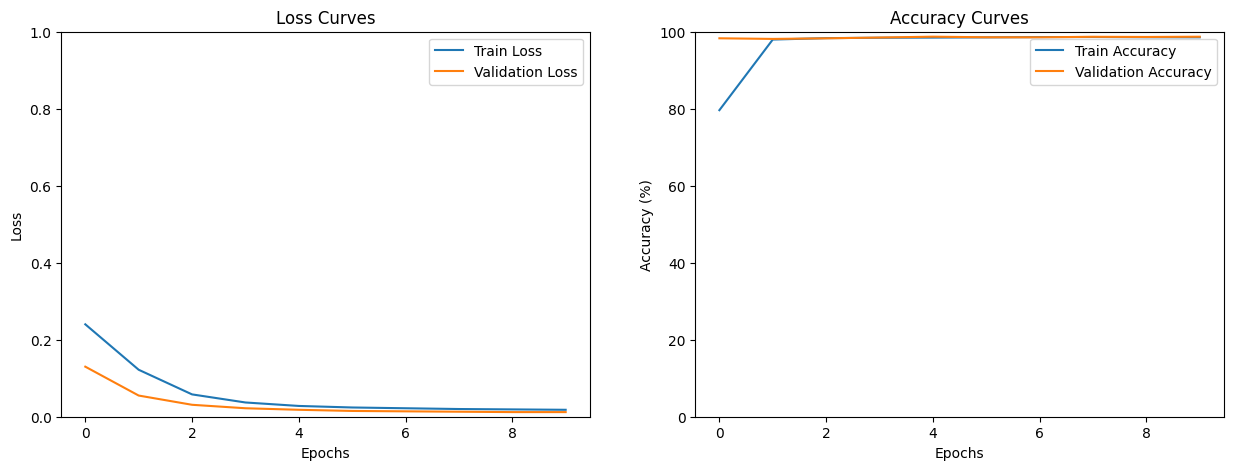

In [41]:
# Plot training and validation loss and accuracy curves
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Train Loss')
axs[0].plot(total_loss_val_plot, label='Validation Loss')
axs[0].set_title('Loss Curves')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim(0, 1)  # Set y-axis limit for better visualization
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Train Accuracy')
axs[1].plot(total_acc_val_plot, label='Validation Accuracy')
axs[1].set_title('Accuracy Curves')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_ylim(0, 100)  # Set y-axis limit for better visualization
axs[1].legend()

In [42]:
# Display all column names in the original DataFrame
original_df.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='object')

In [43]:
# Prepare normalized feature values for a new prediction
area = 2353/original_df['Area'].abs().max()
MajorAxisLength = 81/original_df['MajorAxisLength'].abs().max()
MinorAxisLength = 42/original_df['MinorAxisLength'].abs().max()
Eccentricity = 32/original_df['Eccentricity'].abs().max()
ConvexArea = 12/original_df['ConvexArea'].abs().max()
EquivDiameter = 33/original_df['EquivDiameter'].abs().max()
Extent = 98/original_df['Extent'].abs().max()
Perimeter = 927/original_df['Perimeter'].abs().max()
Roundness = 1/original_df['Roundness'].abs().max()
AspectRation = 24/original_df['AspectRation'].abs().max()

# Pass the normalized features to the model for prediction
my_prediction = model(torch.tensor([
    area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation
], dtype=torch.float32).to(device))


In [44]:
# Output the predicted value for the input features
my_prediction.item()

1.0